# P66 and CD47 k-mer mimicry analysis

Analyzing where P66's binding site k-mer (position 181-187) matches CD47.

In [1]:
import pandas as pd
from sig2kmer import degenerate_protein_chatgpt
from protein_kmer_utils import find_all_occurrences, display_kmer_alignment

## Protein sequences

In [2]:
# P66 from Borrelia burgdorferi
P66_seq = "MKSHILYKLIIFLTTSAAIFAADALKEKDIFKINPWMPTFGFENTSEFRLDMDELVPGFENKSKITIKLKPFEANPELGKDDPFSAYIKVEDLALKAEGKKGDQFKIDVGDITAQINMYDFFIKISTMTDFDFNKESLFSFAPMTGFKSTYYGFPSNDRAVRGTILARGTSKNIGTIQLGYKLPKLDLTFAIGGTGTGNRNQENDKDTPYNKTYQGILYGIQATWKPIKNLLDQNEDTKSVIAETPFELNFGLSGAYGNETFNNSSITYSLKDKSVVGNDLLSPTLSNSAILASFGAKYKLGLTKINDKNTYLILQMGTDFGIDPFASDFSIFGHISKAANFKKETPSDPNKKAEIFDPNGNALNFSKNTELGIAFSTGASIGFAWNKDTGEKESWAIKGSDSYSTRLFGEQDKKSGVALGISYGQNLYRSKDTEKRLKTISENAFQSLNVEISSYEDNKKGIINGLGWITSIGLYDILRQKSVENYPTTISSTTENNQTEQSSTSTKTTTPNLTFEDAMKLGLALYLDYAIPIASISTEAYVVPYIGAYILGPSNKLSSDATKIYLKTGLSLEKLIRFTTISLGWDSNNIIELANKNTNNAAIGSAFLQFKIAYSGS"

# CD47 from human
CD47_seq = "MWPLVAALLLGSACCGSAQLLFNKTKSVEFTFCNDTVVIPCFVTNMEAQNTTEVYVKWKFKGRDIYTFDGALNKSTVPTDFSSAKIEVSQLLKGDASLKMDKSDAVSHTGNYTCEVTELTREGETIIELKYRVVSWFSPNENILIVIFPIFAILLFWGQFGIKTLKYRSGGMDEKTIALLVAGLVITVIVIVGAILFVPGEYSLKNATGLGLIVTSTGILILLHYYVFSTAIGLTSFVIAILVIQVIAYILAVVGLSLCIAACIPMHGPLLISGLSILALAQLLGLVYMKFVASNQKTIQPPRKAVEEPLNAFKESKGMMNDE"

## Convert to HP encoding

In [3]:
P66_hp = degenerate_protein_chatgpt(P66_seq, "hp")
CD47_hp = degenerate_protein_chatgpt(CD47_seq, "hp")

print(f"P66 length: {len(P66_seq)} aa, {len(P66_hp)} HP")
print(f"CD47 length: {len(CD47_seq)} aa, {len(CD47_hp)} HP")

P66 length: 618 aa, 618 HP
CD47 length: 323 aa, 323 HP


## P66 binding site (positions 181-187)

From the paper: D184 and D186 residues in the loop at positions 181-187 are critical for binding.

In [4]:
# Extract P66 binding site
p66_binding_start = 181
p66_binding_end = 188  # exclusive

p66_binding_aa = P66_seq[p66_binding_start:p66_binding_end]
p66_binding_hp = P66_hp[p66_binding_start:p66_binding_end]

print(f"P66 binding site (aa {p66_binding_start}-{p66_binding_end-1}):")
print(f"  Amino acids: {p66_binding_aa}")
print(f"  HP encoding: {p66_binding_hp}")
print(f"  Length: {len(p66_binding_hp)}")

P66 binding site (aa 181-187):
  Amino acids: KLPKLDL
  HP encoding: phhphph
  Length: 7


## Find all occurrences of P66 binding k-mer in CD47

In [5]:
# Find all matches
cd47_matches = find_all_occurrences(CD47_hp, p66_binding_hp)

print(f"K-mer '{p66_binding_hp}' from P66 binding site")
print(f"Found {len(cd47_matches)} occurrence(s) in CD47")
print(f"Positions: {cd47_matches}")

K-mer 'phhphph' from P66 binding site
Found 3 occurrence(s) in CD47
Positions: [63, 89, 124]


## Examine context around each CD47 match

In [6]:
# Show detailed context for each match
context_size = 10

for i, match_pos in enumerate(cd47_matches, 1):
    print(f"\n{'='*70}")
    print(f"Match {i}: CD47 position {match_pos}")
    print(f"{'='*70}")

    # Show HP encoding alignment
    display_kmer_alignment(
        P66_hp,
        CD47_hp,
        p66_binding_start,
        match_pos,
        p66_binding_hp,
        context=context_size,
        query_label="P66",
        match_label="CD47",
    )

    # Show corresponding amino acid sequences
    cd47_aa_start = max(0, match_pos - context_size)
    cd47_aa_end = min(len(CD47_seq), match_pos + len(p66_binding_hp) + context_size)
    p66_aa_start = max(0, p66_binding_start - context_size)
    p66_aa_end = min(
        len(P66_seq), p66_binding_start + len(p66_binding_hp) + context_size
    )

    print("Amino acid sequences:")
    print(
        f" P66: {P66_seq[p66_aa_start:p66_aa_end]} (aa {p66_aa_start}-{p66_aa_end-1})"
    )
    print(
        f"CD47: {CD47_seq[cd47_aa_start:cd47_aa_end]} (aa {cd47_aa_start}-{cd47_aa_end-1})"
    )


Match 1: CD47 position 63
  P66: pphhphphhhphhphphphhhhhphph 171-198
       ..........phhphph..........
 CD47: hhhphphphpphhphphhhpppphhpp 53-80

Amino acid sequences:
 P66: KNIGTIQLGYKLPKLDLTFAIGGTGTG (aa 171-197)
CD47: VYVKWKFKGRDIYTFDGALNKSTVPTD (aa 53-79)

Match 2: CD47 position 89
  P66: pphhphphhhphhphphphhhhhphph 171-198
       ..........phhphph..........
 CD47: phpphphphpphhphphphphpppphh 79-106

Amino acid sequences:
 P66: KNIGTIQLGYKLPKLDLTFAIGGTGTG (aa 171-197)
CD47: DFSSAKIEVSQLLKGDASLKMDKSDAV (aa 79-105)

Match 3: CD47 position 124
  P66: pphhphphhhphhphphphhhhhphph 171-198
       ..........phhphph..........
 CD47: phpphppphpphhphphphhphhphpp 114-141

Amino acid sequences:
 P66: KNIGTIQLGYKLPKLDLTFAIGGTGTG (aa 171-197)
CD47: EVTELTREGETIIELKYRVVSWFSPNE (aa 114-140)


## Test longer k-mers around P66 binding site

Check if extending the k-mer in either direction creates unique matches.

In [7]:
# Test different k-mer lengths centered on binding site
results = []

for kmer_len in range(7, 21):  # Test k=7 to k=20
    # Center the window on the binding site
    offset = (kmer_len - 7) // 2
    start = max(0, p66_binding_start - offset)
    end = start + kmer_len

    if end > len(P66_hp):
        end = len(P66_hp)
        start = end - kmer_len

    kmer_hp = P66_hp[start:end]
    kmer_aa = P66_seq[start:end]

    # Find matches in CD47
    matches = find_all_occurrences(CD47_hp, kmer_hp)

    results.append(
        {
            "kmer_length": kmer_len,
            "p66_start": start,
            "p66_end": end,
            "kmer_hp": kmer_hp,
            "kmer_aa": kmer_aa,
            "n_matches": len(matches),
            "cd47_positions": matches,
        }
    )

# Create summary dataframe
kmer_df = pd.DataFrame(results)
kmer_df

,kmer_length,p66_start,p66_end,kmer_hp,kmer_aa,n_matches,cd47_positions
0,7,181,188,phhphph,KLPKLDL,3,"[63, 89, 124]"
1,8,181,189,phhphphp,KLPKLDLT,2,"[89, 124]"
2,9,180,189,hphhphphp,YKLPKLDLT,0,[]
3,10,180,190,hphhphphph,YKLPKLDLTF,0,[]
4,11,179,190,hhphhphphph,GYKLPKLDLTF,0,[]
5,12,179,191,hhphhphphphh,GYKLPKLDLTFA,0,[]
6,13,178,191,hhhphhphphphh,LGYKLPKLDLTFA,0,[]
7,14,178,192,hhhphhphphphhh,LGYKLPKLDLTFAI,0,[]
8,15,177,192,phhhphhphphphhh,QLGYKLPKLDLTFAI,0,[]
9,16,177,193,phhhphhphphphhhh,QLGYKLPKLDLTFAIG,0,[]


## Find the longest k-mer with at least one match

In [8]:
# Filter to k-mers with matches
with_matches = kmer_df[kmer_df["n_matches"] > 0]

if len(with_matches) > 0:
    longest = with_matches.loc[with_matches["kmer_length"].idxmax()]

    print(f"Longest k-mer with matches: k={longest['kmer_length']}")
    print(f"P66 positions: {longest['p66_start']}-{longest['p66_end']-1}")
    print(f"Amino acids: {longest['kmer_aa']}")
    print(f"HP encoding: {longest['kmer_hp']}")
    print(f"Number of matches in CD47: {longest['n_matches']}")
    print(f"CD47 positions: {longest['cd47_positions']}")

    # Show the alignment for this longest k-mer
    print(f"\n{'='*70}")
    print(f"Alignment for longest k-mer (k={longest['kmer_length']}):")
    print(f"{'='*70}")

    for match_pos in longest["cd47_positions"]:
        display_kmer_alignment(
            P66_hp,
            CD47_hp,
            longest["p66_start"],
            match_pos,
            longest["kmer_hp"],
            context=10,
            query_label="P66",
            match_label="CD47",
        )
else:
    print("No k-mers found with matches!")

Longest k-mer with matches: k=8
P66 positions: 181-188
Amino acids: KLPKLDLT
HP encoding: phhphphp
Number of matches in CD47: 2
CD47 positions: [89, 124]

Alignment for longest k-mer (k=8):
  P66: pphhphphhhphhphphphhhhhphphp 171-199
       ..........phhphphp..........
 CD47: phpphphphpphhphphphphpppphhp 79-107

  P66: pphhphphhhphhphphphhhhhphphp 171-199
       ..........phhphphp..........
 CD47: phpphppphpphhphphphhphhphppp 114-142



## Summary visualization

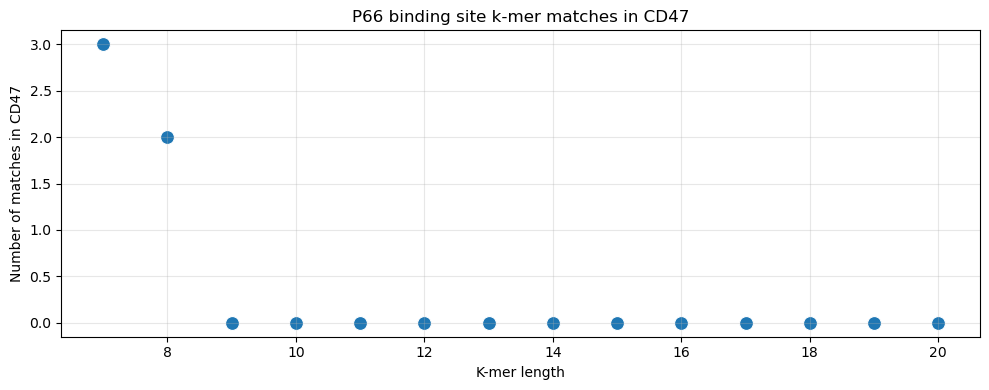

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot k-mer length vs number of matches
fig, ax = plt.subplots(figsize=(10, 4))
sns.scatterplot(data=kmer_df, x="kmer_length", y="n_matches", s=100, ax=ax)
ax.set_xlabel("K-mer length")
ax.set_ylabel("Number of matches in CD47")
ax.set_title("P66 binding site k-mer matches in CD47")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()